In this project, we're working for a client who wants to create a model that can predict the price of apartments in the city of Buenos Aires — with a focus on apartments that cost less than $400,000 USD.

In [15]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In [16]:
df = pd.read_csv('./buenos-aires-real-estate-active.csv');

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8606 entries, 0 to 8605
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   8606 non-null   object 
 1   property_type               8606 non-null   object 
 2   place_with_parent_names     8606 non-null   object 
 3   lat-lon                     6936 non-null   object 
 4   price                       7590 non-null   float64
 5   currency                    7590 non-null   object 
 6   price_aprox_local_currency  7590 non-null   float64
 7   price_aprox_usd             7590 non-null   float64
 8   surface_total_in_m2         5946 non-null   float64
 9   surface_covered_in_m2       7268 non-null   float64
 10  price_usd_per_m2            4895 non-null   float64
 11  price_per_m2                6520 non-null   float64
 12  floor                       1259 non-null   float64
 13  rooms                       4752 

For this project, we want to build a model for apartments in Buenos Aires proper (`"Capital Federal"`) that cost less than \$400,000. Looking at the first five rows of our DataFrame, we can already see that there properties that fall outside those parameters. So our first cleaning task is to remove those observations from our dataset. Since we're using a function to import and clean our data, we'll need to make changes there. 

In [18]:
def wrangle(filepath): 
    df = pd.read_csv(filepath)
    #Filter for Capital Federal returns Series
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    #Filter for apartment types returns Series
    mask_apt = df["property_type"] == "apartment"
    #Filter for price in usd less than 400,000 _ is used to distinguish while reading
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[ mask_ba & mask_apt & mask_price]
    return df

In [19]:
wrangle("./buenos-aires-real-estate-active.csv"); #df within the wrangle is local variable so df that is passed will not mutate unless we use inplace=True kind of functions

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8606 entries, 0 to 8605
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   8606 non-null   object 
 1   property_type               8606 non-null   object 
 2   place_with_parent_names     8606 non-null   object 
 3   lat-lon                     6936 non-null   object 
 4   price                       7590 non-null   float64
 5   currency                    7590 non-null   object 
 6   price_aprox_local_currency  7590 non-null   float64
 7   price_aprox_usd             7590 non-null   float64
 8   surface_total_in_m2         5946 non-null   float64
 9   surface_covered_in_m2       7268 non-null   float64
 10  price_usd_per_m2            4895 non-null   float64
 11  price_per_m2                6520 non-null   float64
 12  floor                       1259 non-null   float64
 13  rooms                       4752 

In [21]:
df = wrangle("./buenos-aires-real-estate-active.csv"); # to mutate the original object

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1781 entries, 0 to 8604
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   1781 non-null   object 
 1   property_type               1781 non-null   object 
 2   place_with_parent_names     1781 non-null   object 
 3   lat-lon                     1723 non-null   object 
 4   price                       1781 non-null   float64
 5   currency                    1781 non-null   object 
 6   price_aprox_local_currency  1781 non-null   float64
 7   price_aprox_usd             1781 non-null   float64
 8   surface_total_in_m2         1247 non-null   float64
 9   surface_covered_in_m2       1635 non-null   float64
 10  price_usd_per_m2            1198 non-null   float64
 11  price_per_m2                1618 non-null   float64
 12  floor                       482 non-null    float64
 13  rooms                       1385 non-n

In [23]:
df.head()

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
11,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6050060697,-58.4001162302",60000.0,USD,909744.0,60000.0,28.0,28.0,2142.857143,2142.857143,NaN,1.0,NaN,http://once.properati.com.ar/zz0q_venta_depart...
20,sell,apartment,|Argentina|Capital Federal|San Nicolás|,"-34.603898,-58.378617",69000.0,USD,1046205.6,69000.0,NaN,22.0,NaN,3136.363636,23.0,2.0,NaN,http://san-nicolas.properati.com.ar/rnju_venta...


let's look at the distribution of apartment sizes in our dataset, to see how it affects the price

Text(0.5, 1.0, 'Distribution of Apartment Sizes')

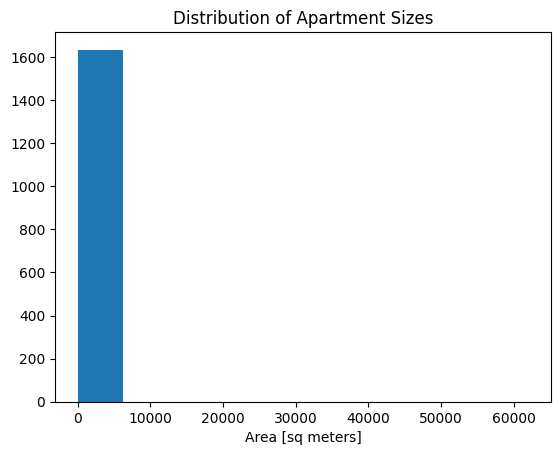

In [24]:
plt.hist(df["surface_covered_in_m2"]);
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Apartment Sizes")

Yikes! When you see a histogram like the one above, it suggests that there are outliers in our dataset. This can affect model performance — especially in the sorts of linear models. To confirm, let's look at the summary statistics for the "surface_covered_in_m2" feature.

In [26]:
df.describe()["surface_covered_in_m2"]

count     1635.000000
mean        97.877064
std       1533.057610
min          0.000000
25%         38.000000
50%         50.000000
75%         73.000000
max      62034.000000
Name: surface_covered_in_m2, dtype: float64

count     1635.000000
mean        97.877064
std       1533.057610
min          0.000000
25%         38.000000
50%         50.000000
75%         73.000000
max      62034.000000
Name: surface_covered_in_m2, dtype: float64 suggests skew in data as min = 0? and max = 62034? and std >>> mean ...this call for more Data Wrangling